# Financial Timeseries — Lakehouse Stack Smoke Test

This notebook writes a sample OHLCV dataset to the lakehouse stack and demonstrates analytical queries.

**Stack:** SeaweedFS (S3) → Polaris (Iceberg REST catalog) → Trino (SQL engine)

**Running from JupyterHub in the same cluster:** no port-forward needed — Trino is reachable via cluster DNS (`trino.lakehouse.svc.cluster.local:8080`).

**Running locally:** start the port-forward first:
```bash
kubectl port-forward -n lakehouse svc/trino 8080:8080
```
Then change `TRINO_HOST` below to `"localhost"`.

In [ ]:
%pip install trino pandas numpy matplotlib seaborn --quiet

## 1. Connect to Trino

In [8]:
import trino
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
from datetime import date

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

TRINO_HOST = "localhost"  # change to "localhost" if running locally
TRINO_PORT = 8080
CATALOG     = "prod"
S3_BUCKET   = "shared-lake-bucket"  # S3 bucket backing this catalog (CATALOG_<name>_BUCKET in env.mk)
SCHEMA      = "price"
TABLE       = f"{CATALOG}.{SCHEMA}.price_data"

conn = trino.dbapi.connect(
    host=TRINO_HOST,
    port=TRINO_PORT,
    user="admin",
    catalog=CATALOG,
    schema=SCHEMA,
    http_scheme="http",
)

def q(sql, fetch=True):
    """Run a SQL query and optionally return results as a DataFrame."""
    cur = conn.cursor()
    cur.execute(sql)
    if fetch:
        cols = [d[0] for d in cur.description]
        return pd.DataFrame(cur.fetchall(), columns=cols)
    cur.fetchall()  # drain the cursor
    return None

version = q("SELECT version()")
print(f"Trino {version.iloc[0,0]} — connected.")

Trino 480 — connected.


## 2. Create Schema and Iceberg Table

In [2]:
q(f"""
    CREATE SCHEMA IF NOT EXISTS {CATALOG}.{SCHEMA}
    WITH (location = 's3://{S3_BUCKET}/{CATALOG}/{SCHEMA}/')
""", fetch=False)

q(f"""
    CREATE TABLE IF NOT EXISTS {TABLE} (
        ticker       VARCHAR        COMMENT 'Ticker symbol',
        trade_date   DATE           COMMENT 'Trading date (business days only)',
        open_price   DECIMAL(12, 4) COMMENT 'Opening price',
        high_price   DECIMAL(12, 4) COMMENT 'Intraday high',
        low_price    DECIMAL(12, 4) COMMENT 'Intraday low',
        close_price  DECIMAL(12, 4) COMMENT 'Closing price',
        volume       BIGINT         COMMENT 'Shares traded',
        vwap         DECIMAL(12, 4) COMMENT 'Volume-weighted average price'
    )
    COMMENT 'Daily OHLCV data — partitioned by ticker and month'
    WITH (
        format       = 'PARQUET',
        partitioning = ARRAY['ticker', 'month(trade_date)']
    )
""", fetch=False)

print(f"Table {TABLE} is ready.")
q(f"SHOW COLUMNS FROM {TABLE}")

Table prod.price.price_data is ready.


,Column,Type,Extra,Comment
0,ticker,varchar,,Ticker symbol
1,trade_date,date,,Trading date (business days only)
2,open_price,"decimal(12,4)",,Opening price
3,high_price,"decimal(12,4)",,Intraday high
4,low_price,"decimal(12,4)",,Intraday low
5,close_price,"decimal(12,4)",,Closing price
6,volume,bigint,,Shares traded
7,vwap,"decimal(12,4)",,Volume-weighted average price


## 3. Generate Synthetic OHLCV Data

Prices follow **Geometric Brownian Motion** — the standard model for equity prices.
Each ticker gets its own drift and volatility, producing realistic-looking time series.

In [3]:
np.random.seed(42)

TICKERS = {
    #  ticker   initial_price  annual_return  annual_vol
    "AAPL":  (182.00, 0.28, 0.24),
    "MSFT":  (375.00, 0.32, 0.22),
    "GOOGL": (140.00, 0.22, 0.26),
    "AMZN":  (153.00, 0.35, 0.30),
    "META":  (350.00, 0.48, 0.35),
    "NVDA":  (495.00, 0.90, 0.55),
    "JPM":   (197.00, 0.18, 0.18),
    "GS":    (390.00, 0.15, 0.20),
}

START_DATE = "2024-01-01"
END_DATE   = "2024-12-31"

def generate_ohlcv(ticker, initial_price, annual_return, annual_vol):
    """Geometric Brownian Motion → OHLCV DataFrame."""
    dates = pd.bdate_range(start=START_DATE, end=END_DATE)  # business days only
    n = len(dates)
    dt = 1 / 252

    # Daily log-returns
    log_ret = ((annual_return - 0.5 * annual_vol**2) * dt
               + annual_vol * np.sqrt(dt) * np.random.randn(n))
    close = initial_price * np.exp(np.cumsum(log_ret))

    # Intraday spread around close
    spread = np.abs(np.random.normal(0, annual_vol * np.sqrt(dt), n)) * close
    direction = np.random.choice([-1, 1], size=n)
    open_p  = (close + direction * spread * 0.4).clip(min=0.01)
    high_p  = np.maximum(close, open_p) + spread * 0.6
    low_p   = np.minimum(close, open_p) - spread * 0.4
    low_p   = low_p.clip(min=0.01)
    vwap    = (open_p + high_p + low_p + close) / 4

    # Volume: log-normal with 20-day autocorrelation
    vol_base = int(initial_price * 5_000)
    volume   = (vol_base * np.random.lognormal(0, 0.4, n)).astype(int)

    return pd.DataFrame({
        "ticker":      ticker,
        "trade_date":  dates.date,
        "open_price":  open_p.round(4),
        "high_price":  high_p.round(4),
        "low_price":   low_p.round(4),
        "close_price": close.round(4),
        "volume":      volume,
        "vwap":        vwap.round(4),
    })

frames = [generate_ohlcv(t, *p) for t, p in TICKERS.items()]
df = pd.concat(frames, ignore_index=True)

print(f"Generated {len(df):,} rows across {df['ticker'].nunique()} tickers")
print(f"Date range: {df['trade_date'].min()} → {df['trade_date'].max()}")
df.head()

Generated 2,096 rows across 8 tickers
Date range: 2024-01-01 → 2024-12-31


,ticker,trade_date,open_price,high_price,low_price,close_price,volume,vwap
0,AAPL,2024-01-01,187.1527,192.5496,179.9569,183.5548,1279651,185.8035
1,AAPL,2024-01-02,184.4900,186.1938,182.2183,183.3542,359656,184.0641
2,AAPL,2024-01-03,185.0600,185.7677,184.7769,185.3431,830055,185.2369
3,AAPL,2024-01-04,191.2820,193.4309,188.4169,189.8495,1169931,190.7448
4,AAPL,2024-01-05,187.4978,192.1714,185.6284,189.3672,1512463,188.6662


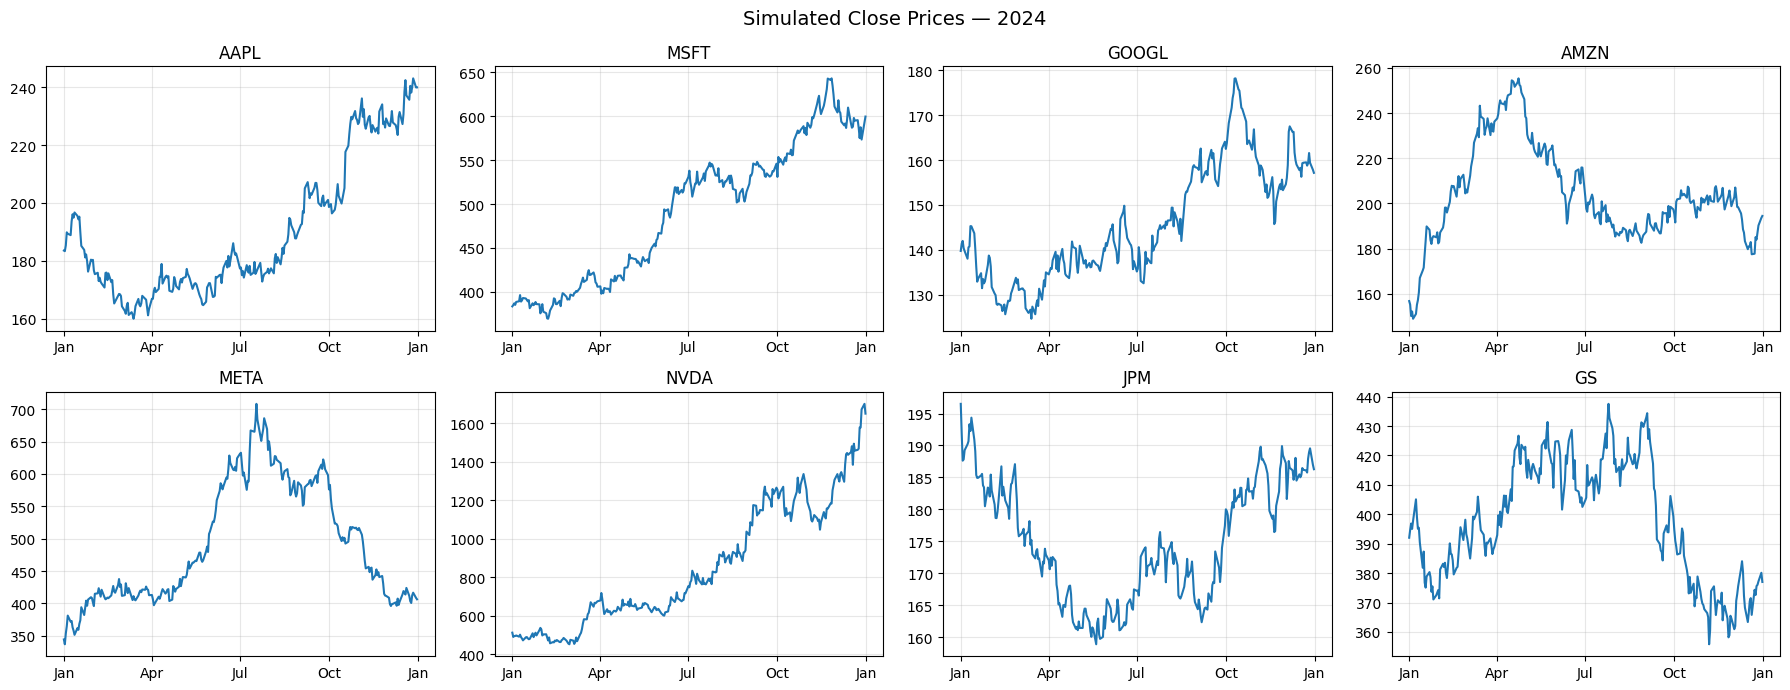

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), tight_layout=True)
fig.suptitle("Simulated Close Prices — 2024", fontsize=14)

for ax, ticker in zip(axes.flat, TICKERS):
    sub = df[df["ticker"] == ticker]
    ax.plot(sub["trade_date"], sub["close_price"])
    ax.set_title(ticker)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.show()

## 4. Upsert Data into Trino / Iceberg

In [ ]:
# Uncomment to delete all rows from the table before upserting (full reload).
# q(f"DELETE FROM {TABLE}", fetch=False)
# print(f"All rows deleted from {TABLE}.")

In [5]:
def upsert_df(df, table, batch_size=200):
    """Batch-merge a DataFrame into a Trino/Iceberg table.
    Rows matching on (ticker, trade_date) are updated; unmatched rows are inserted.
    """
    cur = conn.cursor()
    total = len(df)
    merged = 0

    for start in range(0, total, batch_size):
        batch = df.iloc[start : start + batch_size]
        values = ", ".join(
            "("
            f"'{r.ticker}', "
            f"DATE '{r.trade_date}', "
            f"DECIMAL '{r.open_price}', "
            f"DECIMAL '{r.high_price}', "
            f"DECIMAL '{r.low_price}', "
            f"DECIMAL '{r.close_price}', "
            f"BIGINT '{r.volume}', "
            f"DECIMAL '{r.vwap}'"
            ")"
            for r in batch.itertuples()
        )
        cur.execute(f"""
            MERGE INTO {table} AS t
            USING (
                SELECT *
                FROM (VALUES {values})
                    AS v(ticker, trade_date, open_price, high_price, low_price,
                         close_price, volume, vwap)
            ) AS s
            ON t.ticker = s.ticker AND t.trade_date = s.trade_date
            WHEN MATCHED THEN
                UPDATE SET
                    open_price  = s.open_price,
                    high_price  = s.high_price,
                    low_price   = s.low_price,
                    close_price = s.close_price,
                    volume      = s.volume,
                    vwap        = s.vwap
            WHEN NOT MATCHED THEN
                INSERT (ticker, trade_date, open_price, high_price, low_price,
                        close_price, volume, vwap)
                VALUES (s.ticker, s.trade_date, s.open_price, s.high_price,
                        s.low_price, s.close_price, s.volume, s.vwap)
        """)
        cur.fetchall()
        merged += len(batch)
        print(f"  {merged:>5} / {total} rows", end="\r")

    print(f"  {merged:>5} / {total} rows — done.")
    return merged

print(f"Upserting {len(df):,} rows into {TABLE} ...")
n = upsert_df(df, TABLE)
print(f"\nLoaded {n:,} rows.")

Upserting 2,096 rows into prod.price.price_data ...
   2096 / 2096 rows — done.

Loaded 2,096 rows.


## 5. Verify the Data

In [6]:
summary = q(f"""
    SELECT
        ticker,
        COUNT(*)                        AS trading_days,
        MIN(trade_date)                 AS first_date,
        MAX(trade_date)                 AS last_date,
        MIN(CAST(low_price  AS DOUBLE)) AS price_min,
        MAX(CAST(high_price AS DOUBLE)) AS price_max,
        ROUND(SUM(volume) / 1e6, 1)    AS total_volume_m
    FROM {TABLE}
    GROUP BY ticker
    ORDER BY ticker
""")
summary

,ticker,trading_days,first_date,last_date,price_min,price_max,total_volume_m
0,AAPL,262,2024-01-01,2024-12-31,158.7473,245.0095,248.0
1,AMZN,262,2024-01-01,2024-12-31,146.9837,259.8872,221.9
2,GOOGL,262,2024-01-01,2024-12-31,123.5836,182.7882,197.7
3,GS,262,2024-01-01,2024-12-31,355.4211,442.0656,561.7
4,JPM,262,2024-01-01,2024-12-31,157.0024,198.5173,280.4
5,META,262,2024-01-01,2024-12-31,334.7860,728.4901,494.2
6,MSFT,262,2024-01-01,2024-12-31,363.9655,651.6598,538.3
7,NVDA,262,2024-01-01,2024-12-31,433.1649,1778.8221,700.5


## 6. Analytical Queries

### 6.1 Daily Log-Returns (SQL window function)

In [7]:
returns = q(f"""
    SELECT
        ticker,
        trade_date,
        CAST(close_price AS DOUBLE) AS close,
        LN(
            CAST(close_price AS DOUBLE)
            / LAG(CAST(close_price AS DOUBLE)) OVER (
                PARTITION BY ticker ORDER BY trade_date
            )
        ) AS log_return
    FROM {TABLE}
    ORDER BY ticker, trade_date
""")

returns_pivot = returns.dropna().pivot(index="trade_date", columns="ticker", values="log_return")
returns_pivot.head()

ticker,AAPL,AMZN,GOOGL,GS,JPM,META,MSFT,NVDA
trade_date,,,,,,,,
2024-01-02,-0.001093,-0.010082,0.011735,0.006757,-0.024310,-0.021847,0.004135,-0.044438
2024-01-03,0.010789,-0.033034,0.004230,0.005469,-0.022015,0.048508,0.004868,0.009883
2024-01-04,0.024023,0.013316,-0.011577,-0.004581,0.001036,0.031015,-0.004389,0.000167
2024-01-05,-0.002544,-0.021493,-0.004487,0.006881,0.007610,0.044002,0.008630,0.005705
2024-01-08,-0.002543,0.014286,-0.012299,0.018234,0.004907,-0.025301,0.001838,-0.013014


### 6.2 Realized Volatility (30-day rolling, annualised)

In [ ]:
rvol = (
    returns_pivot
    .rolling(30)
    .std()
    .multiply(np.sqrt(252))  # annualise
    .dropna()
)

ax = rvol.plot(title="30-Day Realised Volatility (annualised)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

### 6.3 20 / 50-Day Moving Averages (Trino SQL)

In [ ]:
ma = q(f"""
    SELECT
        ticker,
        trade_date,
        CAST(close_price AS DOUBLE) AS close,
        AVG(CAST(close_price AS DOUBLE)) OVER (
            PARTITION BY ticker
            ORDER BY trade_date
            ROWS BETWEEN 19 PRECEDING AND CURRENT ROW
        ) AS ma20,
        AVG(CAST(close_price AS DOUBLE)) OVER (
            PARTITION BY ticker
            ORDER BY trade_date
            ROWS BETWEEN 49 PRECEDING AND CURRENT ROW
        ) AS ma50
    FROM {TABLE}
    ORDER BY ticker, trade_date
""")

fig, axes = plt.subplots(2, 4, figsize=(18, 8), tight_layout=True)
fig.suptitle("Close Price with 20-day and 50-day Moving Averages", fontsize=14)

for ax, ticker in zip(axes.flat, TICKERS):
    sub = ma[ma["ticker"] == ticker]
    ax.plot(sub["trade_date"], sub["close"],  lw=1,   label="Close", color="steelblue")
    ax.plot(sub["trade_date"], sub["ma20"],   lw=1.5, label="MA20",  color="orange")
    ax.plot(sub["trade_date"], sub["ma50"],   lw=1.5, label="MA50",  color="crimson")
    ax.set_title(ticker)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    if ticker == "AAPL":
        ax.legend(fontsize=8)

plt.show()

### 6.4 Return Correlation Matrix

In [ ]:
corr = returns_pivot.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1, center=0,
    linewidths=0.5,
    mask=mask,
    ax=ax,
)
ax.set_title("Daily Log-Return Correlations — 2024")
plt.tight_layout()
plt.show()

### 6.5 Monthly VWAP vs Close (Trino aggregation)

In [ ]:
monthly = q(f"""
    SELECT
        ticker,
        DATE_TRUNC('month', trade_date)                     AS month,
        ROUND(AVG(CAST(close_price AS DOUBLE)), 2)          AS avg_close,
        ROUND(
            SUM(CAST(vwap AS DOUBLE) * volume)
            / NULLIF(SUM(volume), 0),
        2)                                                  AS true_vwap,
        SUM(volume)                                         AS total_volume
    FROM {TABLE}
    GROUP BY ticker, DATE_TRUNC('month', trade_date)
    ORDER BY ticker, month
""")

monthly["vwap_vs_close_bps"] = (monthly["true_vwap"] / monthly["avg_close"] - 1) * 10000
print("Monthly VWAP vs Avg-Close spread (basis points):")
monthly.pivot(index="month", columns="ticker", values="vwap_vs_close_bps").round(1)

### 6.6 Iceberg Metadata — Table Snapshots

In [ ]:
snapshots = q(f"""
    SELECT
        snapshot_id,
        committed_at,
        operation,
        element_at(summary, 'added-records')    AS added_records,
        element_at(summary, 'total-records')    AS total_records,
        element_at(summary, 'total-data-files') AS data_files
    FROM {CATALOG}.{SCHEMA}."stock_prices$snapshots"
    ORDER BY committed_at
""")
print(f"{len(snapshots)} snapshots written to Polaris catalog:")
snapshots

### 6.7 Iceberg Time Travel — Prices as of First Snapshot

In [ ]:
if len(snapshots) > 1:
    first_snap = snapshots.iloc[0]["snapshot_id"]
    current_count = q(f"SELECT COUNT(*) AS cnt FROM {TABLE}").iloc[0, 0]
    old_count = q(
        f"SELECT COUNT(*) AS cnt FROM {TABLE} FOR VERSION AS OF {first_snap}"
    ).iloc[0, 0]
    print(f"Current snapshot  : {current_count:,} rows")
    print(f"First snapshot    : {old_count:,} rows  (snapshot {first_snap})")
else:
    print("Only one snapshot — insert more data to demonstrate time travel.")

### 6.8 Cumulative Returns — Equity Curve

In [ ]:
cum_ret = (1 + returns_pivot).cumprod() - 1

ax = cum_ret.plot(
    title="Cumulative Log-Returns — 2024",
    linewidth=2,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.0%}"))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

final_returns = cum_ret.iloc[-1].sort_values(ascending=False)
print("\nFull-year returns:")
for t, r in final_returns.items():
    print(f"  {t:6s}  {r:+.1%}")

## 7. Cleanup (optional)

Run this cell to drop the table and schema when you are done.

In [ ]:
# Uncomment to clean up
# q(f"DROP TABLE IF EXISTS {TABLE}", fetch=False)
# q(f"DROP SCHEMA IF EXISTS {CATALOG}.{SCHEMA}", fetch=False)
# print("Cleaned up.")